# Perovskite Degradation Kinetics

Demonstrates the Scenario pipeline using the **Siegler et al. (2022)** material-level kinetic model for MAPbIâ‚ƒ perovskite degradation.

1. **Multiple jobs in one pipeline** â€” module temperature, surface humidity, and perovskite degradation rate all in a single `run()` call.
2. **Sequential job chaining (`depends_on`)** â€” downstream jobs receive the output of upstream jobs as named keyword arguments at run time.
3. **Four-pathway kinetic rate** [mol mâ»Â² sâ»Â¹] for MAPbIâ‚ƒ: WPO, DPO, humidity-driven, and thermal pathways.

> **See also:** `06_scenario_perovskite_ey.ipynb` â€” device-level Zhao/Orooji model, CE degradation factor, and energy yield prediction with pvlib.

## 1. Imports and data

In [1]:
import os
import json
from pathlib import Path
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt

# Anchor tutorials/data before Scenario changes cwd
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "tutorials" / "data").is_dir() else cwd.parents[1]
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

print(REPO_ROOT)
print(TUTORIALS_DATA)

C:\Users\rdaxini\Documents\GitHub\PVDegradationTools_NREL
C:\Users\rdaxini\Documents\GitHub\PVDegradationTools_NREL\tutorials\data


In [2]:
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(
        f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}Â°N, {mt['longitude']:.2f}Â°E)"
    )

# Single-location aliases used by demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]
display_year = 2020
print(f"\nDisplay year: {display_year}")

  Golden, CO: 8760 rows  (39.73Â°N, -105.18Â°E)


  Miami, FL: 8760 rows  (25.77Â°N, -80.18Â°E)


  New York, NY: 8760 rows  (40.65Â°N, -73.98Â°E)

Display year: 2020


---
## 2. Single job â€” perovskite degradation rate

The simplest use: one job, no sequential dependencies.

`perovskite_degradation` computes the four-pathway kinetic rate:

$$r = r_\text{WPO} + r_\text{DPO} + r_\text{hum} + r_\text{therm}$$

All it needs from the pipeline is `temp_air` and `relative_humidity` from `weather_df`.
The `component` kwarg selects which term (or their sum) to return.

### 2a. Load parameters from the database

`pvdeg.utilities.get_kinetics("D015")` returns D015 as a flat dict â€” the same values the function uses as defaults, but now sourced from the single authoritative location in `DegradationDatabase.json`.
Pass it to the `parameters` argument to use the DB as the source of truth.

In [3]:
d015 = pvdeg.utilities.get_kinetics("D015")
# d015  # Uncomment to see material kinetics details

In [4]:
s1 = pvdeg.Scenario(
    name="perovskite-simple",
    weather_data=weather_df,
    meta_data=meta,
)

# Default: uses hardcoded parameter values from the paper
s1.addJob(func=pvdeg.degradation.perovskite_degradation, name="default_params")

# DB-sourced: same values, but read from DegradationDatabase.json D015
s1.addJob(
    func=(pvdeg.degradation.perovskite_degradation, {"parameters": d015}),
    name="db_params",
)

s1.run()
# display(s1)  # Uncomment to see results

Max abs difference (default vs DB params): 0.0


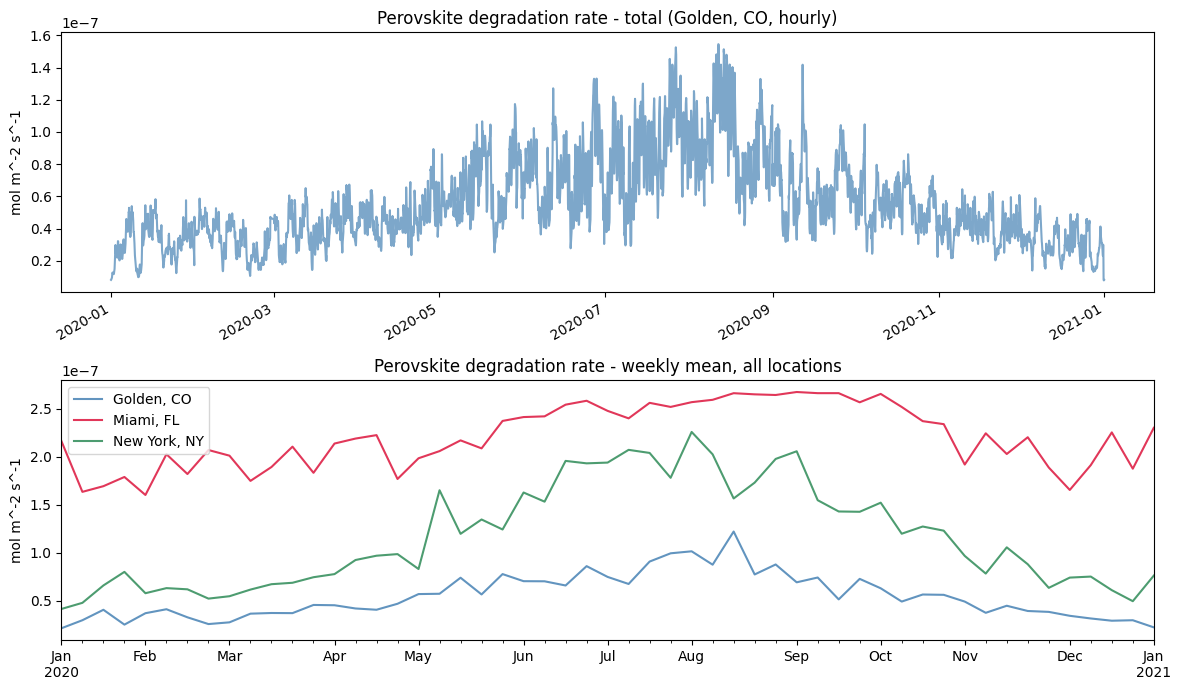

In [5]:
rate_default = s1.results["default_params"]
rate_db = s1.results["db_params"]

print(
    "Max abs difference (default vs DB params):", (rate_default - rate_db).abs().max()
)

# Run all locations using DB params and plot as weekly means for readability
_all_rates = {}
_colors = {
    "Golden, CO": "steelblue",
    "Miami, FL": "crimson",
    "New York, NY": "seagreen",
}
for loc in LOCATIONS:
    sc = pvdeg.Scenario(
        name="rate-loc",
        weather_data=all_weather[loc],
        meta_data=all_meta[loc],
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation, {"parameters": d015}),
        name="rate",
    )
    sc.run()
    _all_rates[loc] = sc.results["rate"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Hourly rate - Golden, CO (raw; demonstrates signal structure)
rate_default.plot(ax=axes[0], color="steelblue", alpha=0.7)
axes[0].set_ylabel("mol m^-2 s^-1")
axes[0].set_title("Perovskite degradation rate - total (Golden, CO, hourly)")

# Weekly mean rate - all locations
for loc, rate in _all_rates.items():
    rate.resample("W").mean().plot(
        ax=axes[1], label=loc, color=_colors[loc], alpha=0.85
    )
axes[1].set_ylabel("mol m^-2 s^-1")
axes[1].set_title("Perovskite degradation rate - weekly mean, all locations")
axes[1].legend()

fig.tight_layout()

---
## 3. Sequential analysis â€” degradation rate as a downstream job

Each job feeds the next via `depends_on`.
The pipeline injects named upstream outputs as keyword arguments at run time â€” no manual wiring needed.

**Chain:**
| Step | Function | Output name | Depends on |
|------|----------|-------------|------------|
| 1 | `temperature.module` | `"temp_mod"` | â€” |
| 2 | `humidity.surface_relative` | `"rh_surface"` | `temp_module` â† `"temp_mod"` |
| 3 | `humidity.water_vapor_pressure` | `"P_H2O"` | `temperature` â† `"temp_mod"`, `rh` â† `"rh_surface"` |
| 4 | `degradation.perovskite_degradation` | `"perov_rate"` | `P_H2O` â† `"P_H2O"` |

Step 2 converts ambient RH to **module-surface RH** using the module temperature.
Step 3 converts that surface RH (and module temperature) into the **water vapour partial pressure** the kinetic model requires.

In [6]:
s2 = pvdeg.Scenario(
    name="perovskite-sequential",
    weather_data=weather_df,
    meta_data=meta,
)

# Job 1 â€” module surface temperature
s2.addJob(
    func=pvdeg.temperature.module,
    name="temp_mod",
)

# Job 2 â€” module-surface RH; uses module temperature from Job 1
s2.addJob(
    func=(
        pvdeg.humidity.surface_relative,
        {
            "rh_ambient": weather_df["relative_humidity"],
            "temp_ambient": weather_df["temp_air"],
        },
    ),
    name="rh_surface",
    depends_on={"temp_module": "temp_mod"},
)

# Job 3 â€” water vapour pressure at module surface; uses temp and RH from Jobs 1 & 2
s2.addJob(
    func=pvdeg.humidity.water_vapor_pressure,
    name="P_H2O",
    depends_on={"temperature": "temp_mod", "rh": "rh_surface"},
)

# Job 4 â€” perovskite degradation rate; uses P_H2O from Job 3
s2.addJob(
    func=pvdeg.degradation.perovskite_degradation,
    name="perov_rate",
    depends_on={"P_H2O": "P_H2O"},
)

s2.run()
# display(s2)  # Uncomment to see results

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.


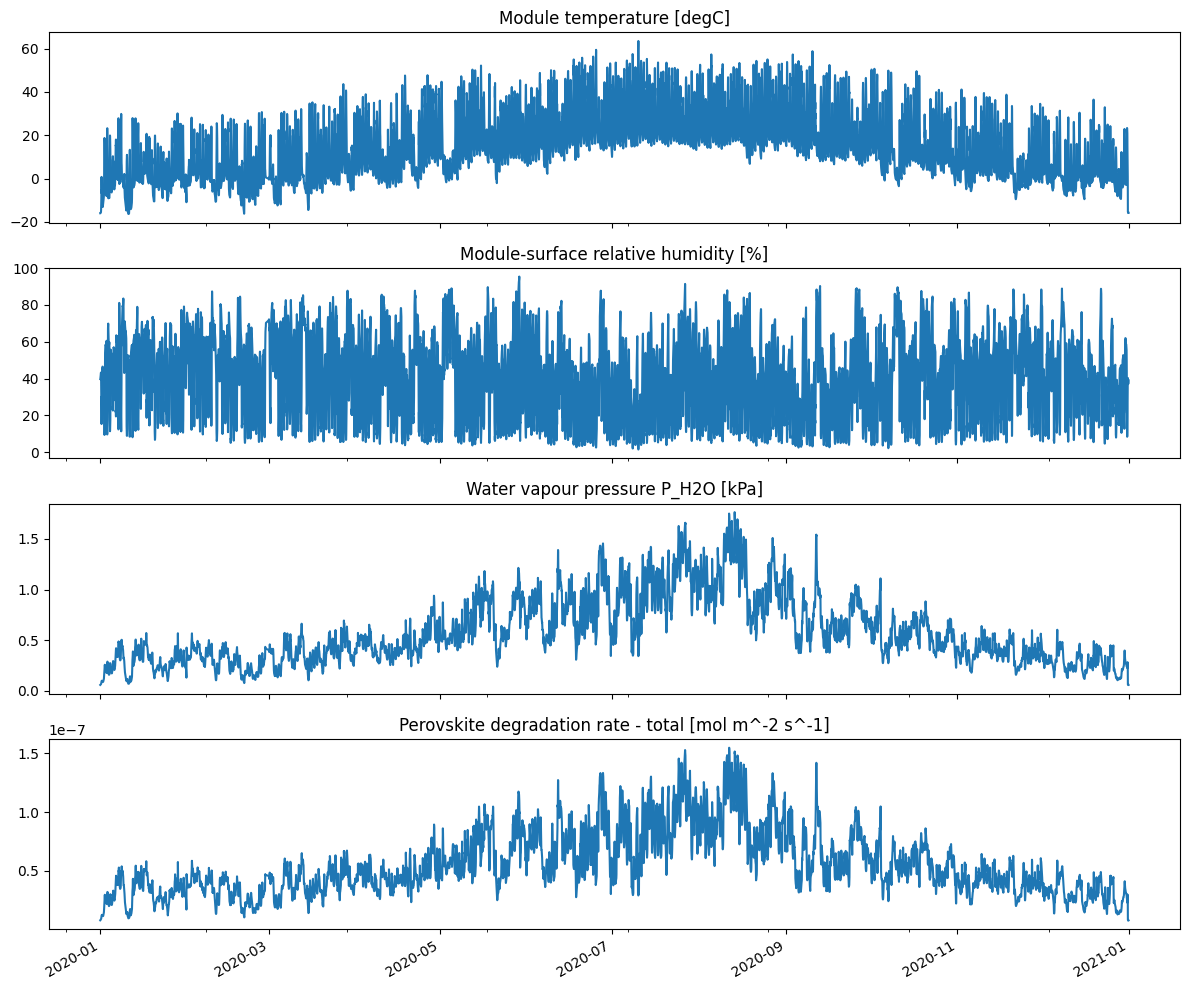

In [7]:
temp_mod = s2.results["temp_mod"]
rh_surf = s2.results["rh_surface"]
p_h2o = s2.results["P_H2O"]
perov = s2.results["perov_rate"]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
temp_mod.plot(ax=axes[0], title="Module temperature [degC]")
rh_surf.plot(ax=axes[1], title="Module-surface relative humidity [%]")
p_h2o.plot(ax=axes[2], title="Water vapour pressure P_H2O [kPa]")
perov.plot(ax=axes[3], title="Perovskite degradation rate - total [mol m^-2 s^-1]")
fig.tight_layout()

### 3b. Component breakdown

Run all four degradation pathways as separate named jobs to compare their contributions.
Each job is independent but they all share the same `weather_df` from the scenario.

<Axes: title={'center': 'Perovskite degradation pathways [mol mâ\x81»Â² sâ\x81»Â¹]'}>

C:\Users\rdaxini\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


C:\Users\rdaxini\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


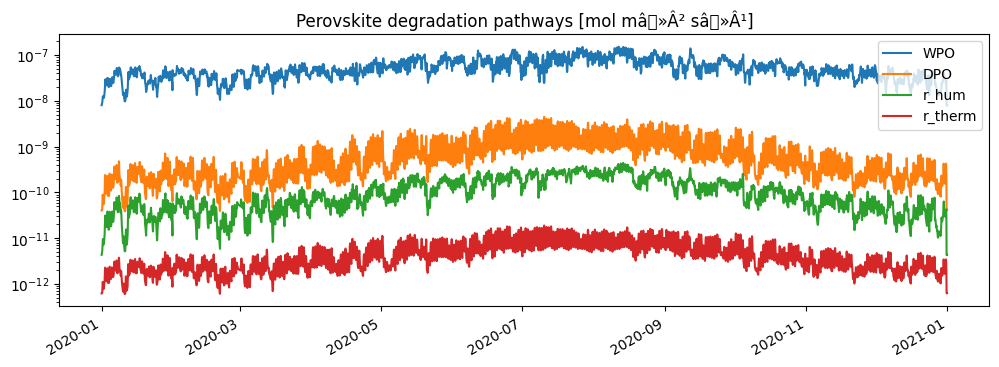

In [8]:
s3 = pvdeg.Scenario(
    name="perovskite-components",
    weather_data=weather_df,
    meta_data=meta,
)

for comp in ("WPO", "DPO", "r_hum", "r_therm"):
    s3.addJob(
        func=(pvdeg.degradation.perovskite_degradation, {"component": comp}),
        name=comp,
    )

s3.run()

# Collect all four component series into a single DataFrame for comparison
components_df = pd.DataFrame(
    {comp: s3.results[comp] for comp in ("WPO", "DPO", "r_hum", "r_therm")}
)
components_df.plot(
    title="Perovskite degradation pathways [mol mâ»Â² sâ»Â¹]",
    figsize=(12, 4),
    logy=True,
)